# MC62 Reproducibility: Test 03 (Feb 16 afternoon) vs Test 04 (Feb 17 morning)

**Magnet**: MC62 (red bulk C-shaped dipole, no shims)  
**PCBs**: Integral (R45) + Central (DQ)  
**Rotation**: 2 Hz (120 rpm), 512 samples/turn  
**Current cycle**: staircase 0→+200→0→−200→0 A in 20 A steps  

Both measurements use identical hardware, Kn calibration, and analysis pipeline.
The goal is to assess day-to-day measurement reproducibility.


In [1]:
from pathlib import Path

REPO = Path(r"C:\Users\albellel\python-projects\rotating-coil-analyzer")

# ── Test 03 (Feb 16 afternoon) ──
MEAS_DIR_03 = REPO / "measurements" / "MC62_20260216_170750_staircase_2Hz" / "aperture1"
BIN_INT_03 = MEAS_DIR_03 / "MC62_20260216_170750_staircase_2Hz_corr_sigs_Ap_1_SegIntegral.bin"
BIN_CEN_03 = MEAS_DIR_03 / "MC62_20260216_170750_staircase_2Hz_corr_sigs_Ap_1_SegCentral.bin"
FFMM_INT_03 = MEAS_DIR_03 / "MC62_20260216_170750_staircase_2Hz_results_Ap_1_Seg_Integral.txt"

# ── Test 04 (Feb 17 morning) ──
MEAS_DIR_04 = REPO / "measurements" / "MC62_20260217_094521_staircase_2Hz_morning" / "aperture1"
BIN_INT_04 = MEAS_DIR_04 / "MC62_20260217_094521_staircase_2Hz_corr_sigs_Ap_1_SegIntegral.bin"
BIN_CEN_04 = MEAS_DIR_04 / "MC62_20260217_094521_staircase_2Hz_corr_sigs_Ap_1_SegCentral.bin"
FFMM_INT_04 = MEAS_DIR_04 / "MC62_20260217_094521_staircase_2Hz_results_Ap_1_Seg_Integral.txt"

# ── Kn calibration (same PCBs for both tests) ──
KN_DIR      = REPO / "measurements" / "2026_02_11_MC62" / "Kn values"
KN_INTEGRAL = KN_DIR / "Kn_R45_PCB_N1_0001_A_AC.txt"
KN_CENTRAL  = KN_DIR / "Kn_DQ_5_18_7_250_47x50_0001_A_AC.txt"

# ── Common parameters ──
MAGNET_ORDER     = 1
R_REF            = 0.033
SAMPLES_PER_TURN = 512
RPM              = 120
N_LAST_TURNS     = 340
N_SKIP_END       = 20

PLATEAU_I_RANGE_MAX = 0.5
PLATEAU_MIN_LENGTH  = 50
PLATEAU_MERGE_GAP   = 100

FLIP_FIELD_SIGN = True
OPTIONS         = ("dri", "rot", "cel", "fed")  # cel/fed applied if diagnostic says SAFE
DRIFT_MODE      = "legacy"
MIN_B1_T        = 1e-6

LABEL_03 = "Test 03 (Feb 16 PM)"
LABEL_04 = "Test 04 (Feb 17 AM)"

print("MC62 reproducibility comparison: test 03 vs test 04")
print(f"  R_ref = {R_REF*1e3:.1f} mm, last {N_LAST_TURNS} turns averaged")


MC62 reproducibility comparison: test 03 vs test 04
  R_ref = 33.0 mm, last 340 turns averaged


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib widget

plt.rcParams.update({
    "figure.figsize": (12, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 100,
})

from rotating_coil_analyzer.analysis.kn_pipeline import load_segment_kn_txt
from rotating_coil_analyzer.analysis.utility_functions import (
    compute_block_averaged_range,
    detect_plateau_turns,
    classify_current,
    find_contiguous_groups,
    process_kn_pipeline,
    build_harmonic_rows,
    plateau_summary,
    plot_hysteresis,
    diagnose_cel_fed,
)
from rotating_coil_analyzer.ingest.channel_detect import robust_range

print("Imports ready.")


Imports ready.


In [3]:
kn_integral = load_segment_kn_txt(str(KN_INTEGRAL))
kn_central  = load_segment_kn_txt(str(KN_CENTRAL))

for lbl, kn in [("Integral (R45)", kn_integral), ("Central (DQ)", kn_central)]:
    print(f"{lbl:20s}: {len(kn.orders):2d} harmonics")


Integral (R45)      : 30 harmonics
Central (DQ)        : 15 harmonics


In [4]:
Ns = SAMPLES_PER_TURN
N_COLS = 4  # time, abs_flux, cmp_flux, current
N_BLOCKS = 10


def load_binary_segment(bin_path):
    """Load a binary corrected-signals file into per-turn arrays."""
    raw = np.fromfile(str(bin_path), dtype="<f8")
    n_samples = len(raw) // N_COLS
    n_turns = n_samples // Ns
    n_keep = n_turns * Ns
    raw = raw[: n_keep * N_COLS].reshape(n_keep, N_COLS)
    t_all   = raw[:, 0].reshape(n_turns, Ns)
    ch1_all = raw[:, 1].reshape(n_turns, Ns)
    ch2_all = raw[:, 2].reshape(n_turns, Ns)
    I_all   = raw[:, 3].reshape(n_turns, Ns)
    return t_all, ch1_all, ch2_all, I_all, n_turns


def detect_channels(ch1, ch2, I_all):
    """Detect absolute vs compensated channel by range at peak current."""
    I_mean = I_all.mean(axis=1)
    best = np.argmax(np.abs(I_mean))
    rr1 = robust_range(ch1[best])
    rr2 = robust_range(ch2[best])
    swap = rr2 > rr1
    flux_abs = ch2 if swap else ch1
    flux_cmp = ch1 if swap else ch2
    return flux_abs, flux_cmp, swap


def find_staircase_groups(I_mean, is_plateau):
    """Find plateau groups, merge, and identify staircase region."""
    groups_raw = find_contiguous_groups(is_plateau, min_length=PLATEAU_MIN_LENGTH)
    group_info = []
    for gi, (gs, ge) in enumerate(groups_raw):
        I_grp = I_mean[gs:ge+1]
        I_nom = round(I_grp.mean() / 20) * 20
        group_info.append({
            "group": gi, "start": gs, "end": ge,
            "n_turns": ge - gs + 1,
            "I_mean": I_grp.mean(), "I_nom": I_nom,
            "I_std": I_grp.std(),
        })

    # Merge consecutive groups at same I_nom
    merged = [group_info[0].copy()]
    for g in group_info[1:]:
        prev = merged[-1]
        gap = g["start"] - prev["end"]
        if g["I_nom"] == prev["I_nom"] and gap < PLATEAU_MERGE_GAP:
            prev["end"] = g["end"]
            prev["n_turns"] = prev["end"] - prev["start"] + 1
            I_slice = I_mean[prev["start"]:prev["end"]+1]
            prev["I_mean"] = I_slice.mean()
            prev["I_std"] = I_slice.std()
        else:
            merged.append(g.copy())
    for i, g in enumerate(merged):
        g["group"] = i

    df_groups = pd.DataFrame(merged)

    # Identify staircase start (first 0 A plateau with >= 500 turns)
    staircase_start_group = 0
    for i, row in df_groups.iterrows():
        if abs(row["I_nom"]) < 2.0 and row["n_turns"] >= 500:
            staircase_start_group = i
            break

    # Check if "precycle" groups are actually systematic staircase steps
    if staircase_start_group > 0:
        pre_I = df_groups.iloc[:staircase_start_group]["I_nom"].values
        if len(pre_I) > 1:
            steps = np.abs(np.diff(pre_I))
            if np.all(steps <= 25):  # systematic 20 A stepping -> no precycle
                print("  No precycle detected (systematic stepping from start)")
                staircase_start_group = 0

    return df_groups, staircase_start_group


def build_staircase_runs(df_groups, staircase_start_group, I_mean):
    """Build run metadata and per-turn lookup for staircase plateau turns."""
    staircase = df_groups[df_groups.index >= staircase_start_group].copy()
    staircase = staircase.reset_index(drop=True)
    staircase["run_id"] = range(len(staircase))
    staircase["I_nom"] = (staircase["I_mean"] / 20).round() * 20

    branches = ["ascending"]
    for i in range(1, len(staircase)):
        if staircase.iloc[i]["I_nom"] > staircase.iloc[i-1]["I_nom"]:
            branches.append("ascending")
        elif staircase.iloc[i]["I_nom"] < staircase.iloc[i-1]["I_nom"]:
            branches.append("descending")
        else:
            branches.append(branches[-1])
    staircase["branch"] = branches

    turn_run_map = {}
    for _, row in staircase.iterrows():
        start, end = int(row["start"]), int(row["end"])
        for t in range(start, end + 1):
            turn_run_map[t] = {
                "run_id": int(row["run_id"]),
                "I_nom": row["I_nom"],
                "branch": row["branch"],
                "turn_in_run": t - start,
            }
    return staircase, turn_run_map


def load_staircase(bin_integral, bin_central, label):
    """Full pipeline: load binary -> plateau detect -> pipeline -> summary.

    Returns (summ_int, summ_cen, df_int, df_cen).
    """
    print(f"\n{'='*60}")
    print(f"  Loading {label}")
    print(f"{'='*60}")

    # 1. Load binary
    t_int, ch1_int, ch2_int, I_int, n_turns = load_binary_segment(bin_integral)
    t_cen, ch1_cen, ch2_cen, I_cen, _       = load_binary_segment(bin_central)
    print(f"  {n_turns} turns loaded")

    # 2. Channel detection
    flux_abs_int, flux_cmp_int, swap_int = detect_channels(ch1_int, ch2_int, I_int)
    flux_abs_cen, flux_cmp_cen, swap_cen = detect_channels(ch1_cen, ch2_cen, I_cen)
    print(f"  Integral: {'SWAP' if swap_int else 'no swap'}, "
          f"Central: {'SWAP' if swap_cen else 'no swap'}")

    # 3. Plateau detection
    I_mean = I_int.mean(axis=1)
    I_range, I_blocks = compute_block_averaged_range(I_int, Ns, N_BLOCKS)
    plateau_info = detect_plateau_turns(I_blocks, I_mean, I_range, PLATEAU_I_RANGE_MAX)
    is_plateau = plateau_info["is_plateau"]
    print(f"  Plateau turns: {is_plateau.sum()} / {n_turns}")

    # 4. Staircase identification
    df_groups, sc_start = find_staircase_groups(I_mean, is_plateau)
    staircase_runs, turn_run_map = build_staircase_runs(df_groups, sc_start, I_mean)
    print(f"  Staircase plateaus: {len(staircase_runs)}")

    # 5. cel/fed diagnostic
    _n_diag = min(100, flux_abs_int.shape[0])
    _diag = diagnose_cel_fed(
        flux_abs_int[:_n_diag], flux_cmp_int[:_n_diag],
        t_int[:_n_diag], I_int[:_n_diag],
        kn=kn_integral, r_ref=R_REF, magnet_order=MAGNET_ORDER,
    )
    local_options = OPTIONS
    if _diag.recommendation == "UNSAFE":
        local_options = tuple(o for o in OPTIONS if o not in ("cel", "fed"))
        print(f"  cel/fed disabled, options = {local_options}")
    else:
        print(f"  cel/fed safe, options = {local_options}")
    del _n_diag, _diag

    # 6. Process pipeline
    plateau_indices = sorted(turn_run_map.keys())
    idx = np.array(plateau_indices)

    def run_pipeline(flux_abs, flux_cmp, t_all, I_all, kn, seg_label, merge_mode):
        result, C_merged, C_units, ok_main = process_kn_pipeline(
            flux_abs_turns=flux_abs[idx],
            flux_cmp_turns=flux_cmp[idx],
            t_turns=t_all[idx],
            I_turns=I_all[idx],
            kn=kn, r_ref=R_REF, magnet_order=MAGNET_ORDER,
            options=local_options, drift_mode=DRIFT_MODE, min_b1_T=MIN_B1_T,
            merge_mode=merge_mode,
        )
        extra = [turn_run_map[t] for t in plateau_indices]
        rows = build_harmonic_rows(result, C_merged, C_units, ok_main,
                                   MAGNET_ORDER, extra)
        df = pd.DataFrame(rows)
        print(f"  {seg_label}: {len(df)} turns, {int(df['ok_main'].sum())} ok")
        return df

    df_int = run_pipeline(flux_abs_int, flux_cmp_int, t_int, I_int,
                          kn_integral, "Integral", "abs_upto_m_cmp_above")
    df_cen = run_pipeline(flux_abs_cen, flux_cmp_cen, t_cen, I_cen,
                          kn_central, "Central", "abs_all")

    # Sign convention
    if FLIP_FIELD_SIGN:
        for _df in [df_int, df_cen]:
            abs_cols = [c for c in _df.columns if c.endswith("_T")]
            _df[abs_cols] *= -1

    # 6. Summary
    summ_int = plateau_summary(df_int, N_LAST_TURNS, n_skip_end=N_SKIP_END)
    summ_cen = plateau_summary(df_cen, N_LAST_TURNS, n_skip_end=N_SKIP_END)
    print(f"  Summary: {len(summ_int)} runs (Integral), {len(summ_cen)} (Central)")

    return summ_int, summ_cen, df_int, df_cen


print("Helper functions defined.")


Helper functions defined.


In [5]:
summ03_int, summ03_cen, df03_int, df03_cen = load_staircase(
    BIN_INT_03, BIN_CEN_03, LABEL_03)

summ04_int, summ04_cen, df04_int, df04_cen = load_staircase(
    BIN_INT_04, BIN_CEN_04, LABEL_04)



  Loading Test 03 (Feb 16 PM)


  35828 turns loaded
  Integral: no swap, Central: no swap
  Plateau turns: 33453 / 35828
  Staircase plateaus: 41
  cel/fed disabled, options = ('dri', 'rot')


  Integral: 30466 turns, 30465 ok


  Central: 30466 turns, 30465 ok


  Summary: 41 runs (Integral), 41 (Central)

  Loading Test 04 (Feb 17 AM)


  32544 turns loaded
  Integral: no swap, Central: no swap
  Plateau turns: 31605 / 32544
  No precycle detected (systematic stepping from start)
  Staircase plateaus: 40
  cel/fed disabled, options = ('dri', 'rot')


  Integral: 31030 turns, 31030 ok


  Central: 31030 turns, 31030 ok


  Summary: 40 runs (Integral), 40 (Central)


In [6]:
# cel/fed diagnostic summary (already applied inside load_staircase)
print("cel/fed diagnostic was applied per-dataset inside load_staircase.")
print("OPTIONS were conditionally adjusted before pipeline execution.")


cel/fed diagnostic was applied per-dataset inside load_staircase.
OPTIONS were conditionally adjusted before pipeline execution.


In [7]:
# Side-by-side dataset overview
overview = pd.DataFrame({
    "Metric": ["Staircase plateaus", "Total plateau turns (Integral)",
               "Good-quality runs", "I range (A)"],
    LABEL_03: [
        len(summ03_int),
        len(df03_int),
        int((summ03_int["quality"] == "good").sum()),
        f"{df03_int['I_nom'].min():.0f} .. {df03_int['I_nom'].max():.0f}",
    ],
    LABEL_04: [
        len(summ04_int),
        len(df04_int),
        int((summ04_int["quality"] == "good").sum()),
        f"{df04_int['I_nom'].min():.0f} .. {df04_int['I_nom'].max():.0f}",
    ],
})
print(overview.to_string(index=False))


                        Metric Test 03 (Feb 16 PM) Test 04 (Feb 17 AM)
            Staircase plateaus                  41                  40
Total plateau turns (Integral)               30466               31030
             Good-quality runs                  41                  40
                   I range (A)         -200 .. 200         -200 .. 200


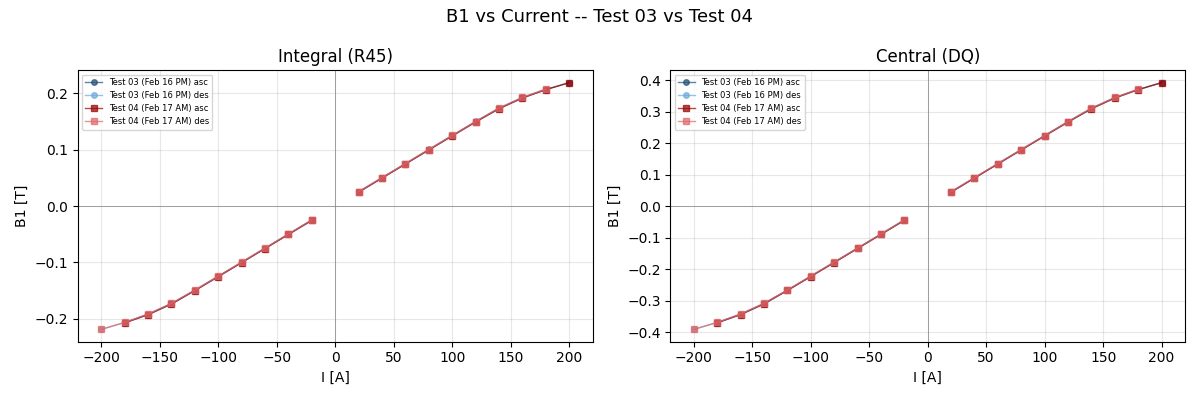

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, s03, s04, seg in [(axes[0], summ03_int, summ04_int, "Integral (R45)"),
                           (axes[1], summ03_cen, summ04_cen, "Central (DQ)")]:
    for summ, lbl, marker, c_asc, c_desc in [
        (s03, LABEL_03, "o", "#1f4e79", "#6fa8dc"),
        (s04, LABEL_04, "s", "#990000", "#e06666"),
    ]:
        good = summ[summ["quality"] == "good"]
        good = good[good["I_nom"].abs() > 2]
        for br, color in [("ascending", c_asc), ("descending", c_desc)]:
            mask = good["branch"] == br
            if mask.any():
                br_data = good.loc[mask].sort_values("run_id")
                I_vals = br_data["I_nom"].values
                breaks = [0] + [i for i in range(1, len(I_vals))
                                if abs(I_vals[i] - I_vals[i-1]) > 30] + [len(I_vals)]
                for j in range(len(breaks) - 1):
                    seg_data = br_data.iloc[breaks[j]:breaks[j+1]]
                    ax.plot(seg_data["I_nom"], seg_data["B1_mean"],
                            marker=marker, ms=4, lw=1, alpha=0.7,
                            color=color,
                            label=f"{lbl} {br[:3]}" if j == 0 else "")
    ax.set_xlabel("I [A]")
    ax.set_ylabel("B1 [T]")
    ax.set_title(seg)
    ax.legend(fontsize=6)
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)

fig.suptitle("B1 vs Current -- Test 03 vs Test 04", fontsize=13)
fig.tight_layout()
plt.show()

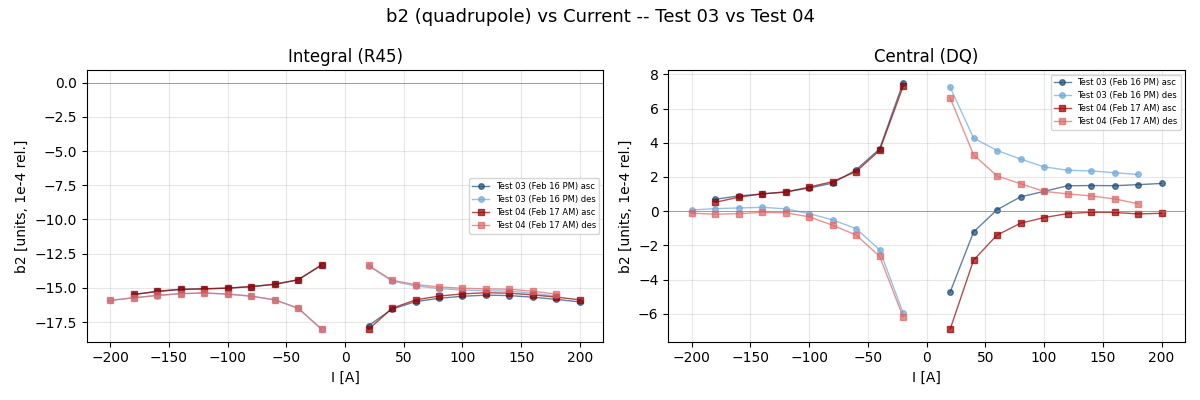

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, s03, s04, seg in [(axes[0], summ03_int, summ04_int, "Integral (R45)"),
                           (axes[1], summ03_cen, summ04_cen, "Central (DQ)")]:
    for summ, lbl, marker, c_asc, c_desc in [
        (s03, LABEL_03, "o", "#1f4e79", "#6fa8dc"),
        (s04, LABEL_04, "s", "#990000", "#e06666"),
    ]:
        good = summ[summ["quality"] == "good"]
        good = good[good["I_nom"].abs() > 2]
        for br, color in [("ascending", c_asc), ("descending", c_desc)]:
            mask = good["branch"] == br
            if mask.any():
                br_data = good.loc[mask].sort_values("run_id")
                I_vals = br_data["I_nom"].values
                breaks = [0] + [i for i in range(1, len(I_vals))
                                if abs(I_vals[i] - I_vals[i-1]) > 30] + [len(I_vals)]
                for j in range(len(breaks) - 1):
                    seg_data = br_data.iloc[breaks[j]:breaks[j+1]]
                    ax.plot(seg_data["I_nom"], seg_data["b2_units_mean"],
                            marker=marker, ms=4, lw=1, alpha=0.7,
                            color=color,
                            label=f"{lbl} {br[:3]}" if j == 0 else "")
    ax.set_xlabel("I [A]")
    ax.set_ylabel("b2 [units, 1e-4 rel.]")
    ax.set_title(seg)
    ax.legend(fontsize=6)
    ax.axhline(0, color="gray", lw=0.5)

fig.suptitle("b2 (quadrupole) vs Current -- Test 03 vs Test 04", fontsize=13)
fig.tight_layout()
plt.show()

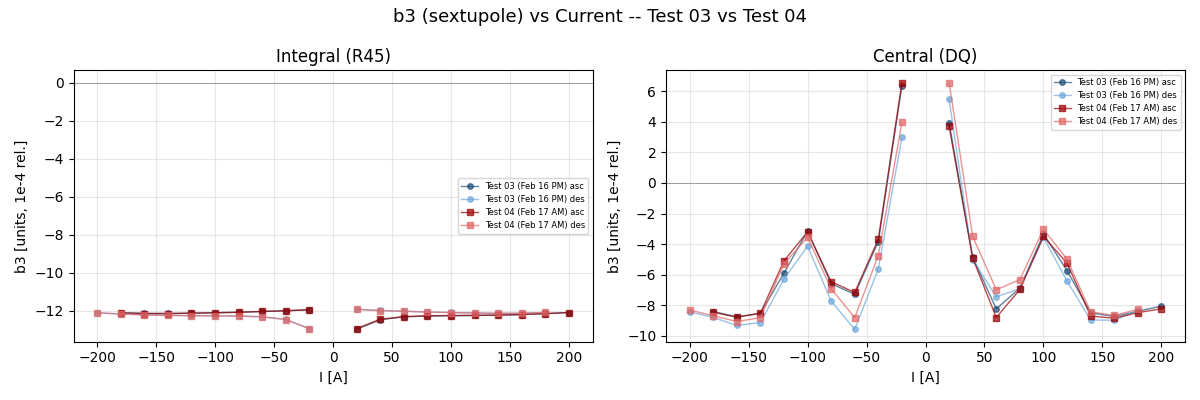

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, s03, s04, seg in [(axes[0], summ03_int, summ04_int, "Integral (R45)"),
                           (axes[1], summ03_cen, summ04_cen, "Central (DQ)")]:
    for summ, lbl, marker, c_asc, c_desc in [
        (s03, LABEL_03, "o", "#1f4e79", "#6fa8dc"),
        (s04, LABEL_04, "s", "#990000", "#e06666"),
    ]:
        good = summ[summ["quality"] == "good"]
        good = good[good["I_nom"].abs() > 2]
        for br, color in [("ascending", c_asc), ("descending", c_desc)]:
            mask = good["branch"] == br
            if mask.any():
                br_data = good.loc[mask].sort_values("run_id")
                I_vals = br_data["I_nom"].values
                breaks = [0] + [i for i in range(1, len(I_vals))
                                if abs(I_vals[i] - I_vals[i-1]) > 30] + [len(I_vals)]
                for j in range(len(breaks) - 1):
                    seg_data = br_data.iloc[breaks[j]:breaks[j+1]]
                    ax.plot(seg_data["I_nom"], seg_data["b3_units_mean"],
                            marker=marker, ms=4, lw=1, alpha=0.7,
                            color=color,
                            label=f"{lbl} {br[:3]}" if j == 0 else "")
    ax.set_xlabel("I [A]")
    ax.set_ylabel("b3 [units, 1e-4 rel.]")
    ax.set_title(seg)
    ax.legend(fontsize=6)
    ax.axhline(0, color="gray", lw=0.5)

fig.suptitle("b3 (sextupole) vs Current -- Test 03 vs Test 04", fontsize=13)
fig.tight_layout()
plt.show()

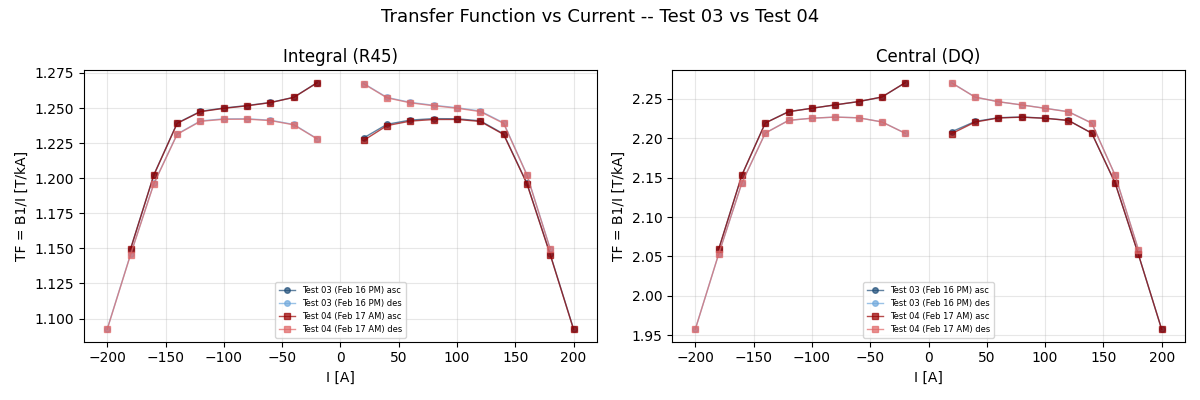

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, s03, s04, seg in [(axes[0], summ03_int, summ04_int, "Integral (R45)"),
                           (axes[1], summ03_cen, summ04_cen, "Central (DQ)")]:
    for summ, lbl, marker, c_asc, c_desc in [
        (s03, LABEL_03, "o", "#1f4e79", "#6fa8dc"),
        (s04, LABEL_04, "s", "#990000", "#e06666"),
    ]:
        good = summ[summ["quality"] == "good"]
        good = good[good["I_nom"].abs() > 2]
        for br, color in [("ascending", c_asc), ("descending", c_desc)]:
            mask = good["branch"] == br
            if mask.any():
                br_data = good.loc[mask].sort_values("run_id")
                I_vals = br_data["I_nom"].values
                breaks = [0] + [i for i in range(1, len(I_vals))
                                if abs(I_vals[i] - I_vals[i-1]) > 30] + [len(I_vals)]
                for j in range(len(breaks) - 1):
                    seg_data = br_data.iloc[breaks[j]:breaks[j+1]]
                    ax.plot(seg_data["I_nom"], seg_data["TF"],
                            marker=marker, ms=4, lw=1, alpha=0.7,
                            color=color,
                            label=f"{lbl} {br[:3]}" if j == 0 else "")
    ax.set_xlabel("I [A]")
    ax.set_ylabel("TF = B1/I [T/kA]")
    ax.set_title(seg)
    ax.legend(fontsize=6)

fig.suptitle("Transfer Function vs Current -- Test 03 vs Test 04", fontsize=13)
fig.tight_layout()
plt.show()

Matched (I_nom, branch) pairs: 41

    I_nom     branch  B1_mean_03  B1_mean_04     dB1  b2_units_mean_03  b2_units_mean_04     db2  b3_units_mean_03  b3_units_mean_04      db3
   0.0000  ascending     -0.0004     -0.0004 -0.0001          108.7978          136.1213 27.3236           37.0518           24.8104 -12.2414
  20.0000  ascending      0.0246      0.0245 -0.0000          -17.7636          -18.0377 -0.2741          -12.9816          -12.9365   0.0450
  40.0000  ascending      0.0495      0.0495 -0.0000          -16.5550          -16.5013  0.0537          -12.4722          -12.4509   0.0213
  60.0000  ascending      0.0745      0.0744 -0.0000          -16.0126          -15.8805  0.1321          -12.3213          -12.3081   0.0131
  80.0000  ascending      0.0994      0.0993 -0.0001          -15.7626          -15.6034  0.1593          -12.2794          -12.2691   0.0103
 100.0000  ascending      0.1242      0.1242 -0.0001          -15.6167          -15.4431  0.1736          -12.260

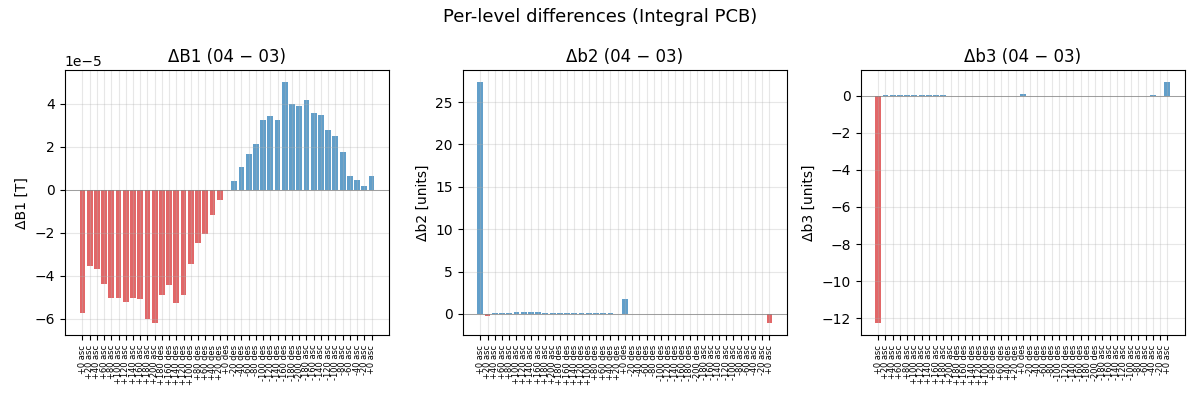

In [12]:
# Merge summaries by (I_nom, branch) for Integral PCB
def merge_summaries(s03, s04):
    """Merge two summary DataFrames on (I_nom, branch)."""
    key = ["I_nom", "branch"]
    m = pd.merge(
        s03[s03["quality"] == "good"],
        s04[s04["quality"] == "good"],
        on=key, suffixes=("_03", "_04"),
    )
    return m

merged_int = merge_summaries(summ03_int, summ04_int)
print(f"Matched (I_nom, branch) pairs: {len(merged_int)}")

# Compute differences
merged_int["dB1"] = merged_int["B1_mean_04"] - merged_int["B1_mean_03"]
merged_int["db2"] = merged_int["b2_units_mean_04"] - merged_int["b2_units_mean_03"]
merged_int["db3"] = merged_int["b3_units_mean_04"] - merged_int["b3_units_mean_03"]
merged_int["dTF"] = merged_int["TF_04"] - merged_int["TF_03"]

# Display
cols = ["I_nom", "branch", "B1_mean_03", "B1_mean_04", "dB1",
        "b2_units_mean_03", "b2_units_mean_04", "db2",
        "b3_units_mean_03", "b3_units_mean_04", "db3"]
print("\n" + merged_int[cols].to_string(index=False, float_format="%.4f"))

# Bar chart of differences
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

x_labels = [f"{r['I_nom']:+.0f} {r['branch'][:3]}" for _, r in merged_int.iterrows()]
x = np.arange(len(x_labels))

for ax, col, ylabel, title in [
    (axes[0], "dB1", "\u0394B1 [T]", "\u0394B1 (04 \u2212 03)"),
    (axes[1], "db2", "\u0394b2 [units]", "\u0394b2 (04 \u2212 03)"),
    (axes[2], "db3", "\u0394b3 [units]", "\u0394b3 (04 \u2212 03)"),
]:
    vals = merged_int[col].values
    colors = ["tab:blue" if v >= 0 else "tab:red" for v in vals]
    ax.bar(x, vals, color=colors, alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=90, fontsize=6)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.axhline(0, color="gray", lw=0.5)

fig.suptitle("Per-level differences (Integral PCB)", fontsize=13)
fig.tight_layout()
plt.show()


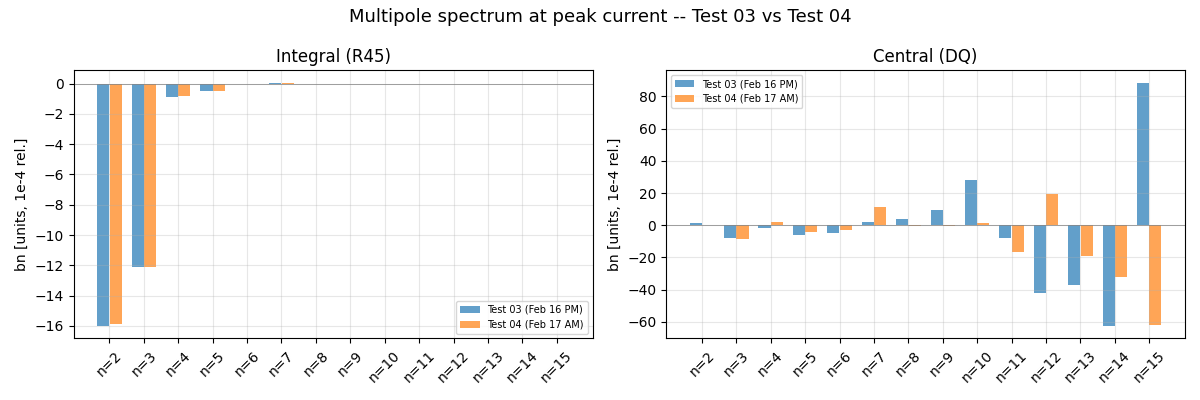

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, s03, s04, seg in [(axes[0], summ03_int, summ04_int, "Integral (R45)"),
                           (axes[1], summ03_cen, summ04_cen, "Central (DQ)")]:
    # Pick ascending peak current from each test
    for summ, lbl, offset in [(s03, LABEL_03, -0.18), (s04, LABEL_04, +0.18)]:
        good = summ[summ["quality"] == "good"]
        if good.empty:
            continue
        peak = good.loc[good["I_nom"].abs().idxmax()]

        orders, bn = [], []
        for n in range(2, 16):
            bc = f"b{n}_units_mean"
            if bc in summ.columns and pd.notna(peak.get(bc)):
                orders.append(n)
                bn.append(peak[bc])

        if orders:
            x = np.arange(len(orders))
            w = 0.35
            ax.bar(x + offset, bn, w, label=f"{lbl}", alpha=0.7)

    if orders:
        ax.set_xticks(np.arange(len(orders)))
        ax.set_xticklabels([f"n={o}" for o in orders], rotation=45)
    ax.set_ylabel("bn [units, 1e-4 rel.]")
    ax.set_title(seg)
    ax.legend(fontsize=7)
    ax.axhline(0, color="gray", lw=0.5)

fig.suptitle("Multipole spectrum at peak current -- Test 03 vs Test 04", fontsize=13)
fig.tight_layout()
plt.show()


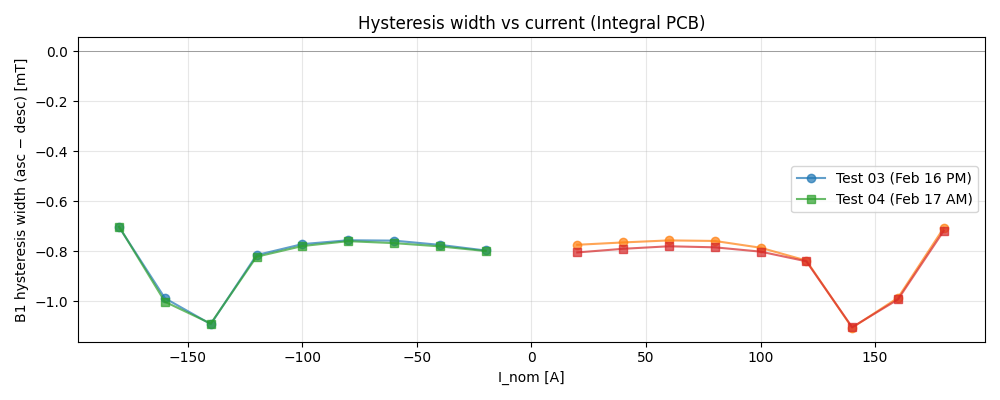

In [14]:
def hysteresis_width(summ):
    """Compute B1_asc - B1_desc for each I_nom."""
    good = summ[summ["quality"] == "good"].copy()
    asc = good[good["branch"] == "ascending"].set_index("I_nom")
    desc = good[good["branch"] == "descending"].set_index("I_nom")
    rows = []
    for I_nom in asc.index:
        if abs(I_nom) < 2:
            continue
        if I_nom in desc.index:
            dB = asc.loc[I_nom, "B1_mean"] - desc.loc[I_nom, "B1_mean"]
            rows.append({"I_nom": I_nom, "hyst_width": dB})
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    # Sort and split at large I_nom gaps to avoid non-physical lines
    df = df.sort_values("I_nom").reset_index(drop=True)
    return df

hyst03 = hysteresis_width(summ03_int)
hyst04 = hysteresis_width(summ04_int)

fig, ax = plt.subplots(figsize=(10, 4))
for hyst, lbl, marker in [(hyst03, LABEL_03, "o-"), (hyst04, LABEL_04, "s-")]:
    if hyst.empty:
        continue
    I_vals = hyst["I_nom"].values
    breaks = [0] + [i for i in range(1, len(I_vals))
                    if abs(I_vals[i] - I_vals[i-1]) > 30] + [len(I_vals)]
    for j in range(len(breaks) - 1):
        seg = hyst.iloc[breaks[j]:breaks[j+1]]
        ax.plot(seg["I_nom"], seg["hyst_width"] * 1e3, marker,
                label=lbl if j == 0 else "", alpha=0.7)
ax.set_xlabel("I_nom [A]")
ax.set_ylabel("B1 hysteresis width (asc \u2212 desc) [mT]")
ax.set_title("Hysteresis width vs current (Integral PCB)")
ax.legend()
ax.axhline(0, color="gray", lw=0.5)
fig.tight_layout()
plt.show()

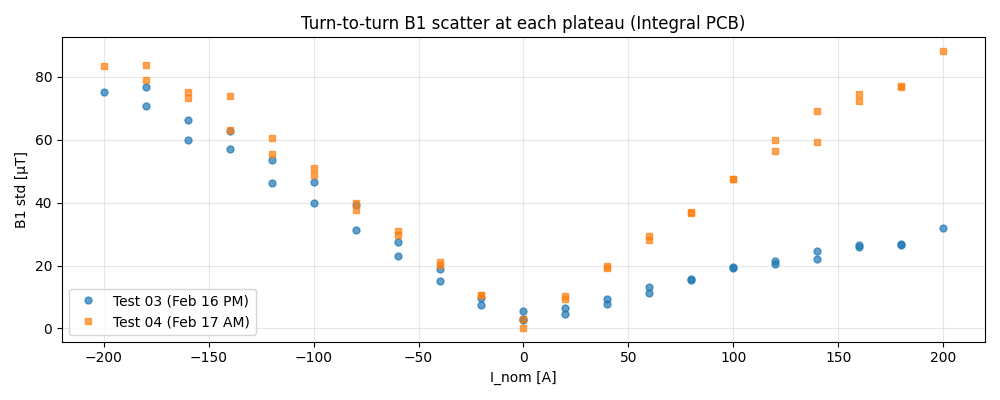

In [15]:
# Compare B1_std at each plateau (measurement noise)
fig, ax = plt.subplots(figsize=(10, 4))

for summ, lbl, marker in [(summ03_int, LABEL_03, "o"),
                           (summ04_int, LABEL_04, "s")]:
    good = summ[summ["quality"] == "good"]
    ax.plot(good["I_nom"], good["B1_std"] * 1e6, marker,
            ms=5, alpha=0.7, label=lbl)

ax.set_xlabel("I_nom [A]")
ax.set_ylabel("B1 std [\u00b5T]")
ax.set_title("Turn-to-turn B1 scatter at each plateau (Integral PCB)")
ax.legend()
fig.tight_layout()
plt.show()


In [16]:
# Summary statistics (Integral PCB)
print("=" * 70)
print("  REPRODUCIBILITY SUMMARY (Integral PCB)")
print("=" * 70)

if len(merged_int) > 0:
    # Exclude I=0 from statistics (remanent field harmonics are unreliable)
    m_nonzero = merged_int[merged_int["I_nom"].abs() > 2].copy()
    print(f"  Matched current levels: {len(merged_int)} total, {len(m_nonzero)} at |I| > 0")
    print()
    for col, unit, label in [
        ("dB1", "T", "ΔB1"),
        ("db2", "units", "Δb2"),
        ("db3", "units", "Δb3"),
        ("dTF", "T/kA", "ΔTF"),
    ]:
        vals = m_nonzero[col].dropna().values
        if len(vals) > 0:
            print(f"  {label} (|I| > 0 only):")
            print(f"    Max |diff|: {np.abs(vals).max():.6f} {unit}")
            print(f"    Mean |diff|: {np.abs(vals).mean():.6f} {unit}")
            print(f"    RMS diff: {np.sqrt(np.mean(vals**2)):.6f} {unit}")
            print()

    # Correlation coefficients (all levels including 0)
    for col03, col04, label in [
        ("B1_mean_03", "B1_mean_04", "B1"),
        ("b2_units_mean_03", "b2_units_mean_04", "b2"),
        ("b3_units_mean_03", "b3_units_mean_04", "b3"),
    ]:
        mask = m_nonzero[col03].notna() & m_nonzero[col04].notna()
        if mask.sum() > 1:
            v03 = m_nonzero.loc[mask, col03].values
            v04 = m_nonzero.loc[mask, col04].values
            corr = np.corrcoef(v03, v04)[0, 1]
            print(f"  Correlation ({label}, |I|>0): r = {corr:.8f}")
else:
    print("  No matched levels found.")


  REPRODUCIBILITY SUMMARY (Integral PCB)
  Matched current levels: 41 total, 38 at |I| > 0

  ΔB1 (|I| > 0 only):
    Max |diff|: 0.000062 T
    Mean |diff|: 0.000033 T
    RMS diff: 0.000037 T

  Δb2 (|I| > 0 only):
    Max |diff|: 0.274067 units
    Mean |diff|: 0.074750 units
    RMS diff: 0.105749 units

  Δb3 (|I| > 0 only):
    Max |diff|: 0.045045 units
    Mean |diff|: 0.007411 units
    RMS diff: 0.010919 units

  ΔTF (|I| > 0 only):
    Max |diff|: 0.001776 T/kA
    Mean |diff|: 0.000355 T/kA
    RMS diff: 0.000453 T/kA

  Correlation (B1, |I|>0): r = 1.00000000
  Correlation (b2, |I|>0): r = 0.99537179
  Correlation (b3, |I|>0): r = 0.99890981


## Observations & Conclusions

### Reproducibility Verdict
*(To be filled after execution.)*

### Main Field (B1)
- Differences at each current level: ...
- Physical significance: ...

### Quadrupole (b2)
- Changes between tests: ...

### Sextupole (b3)
- Changes between tests: ...

### Transfer Function
- Comparison: ...

### Hysteresis
- Width comparison: ...

### Advice for Next Measurements
- ...


In [17]:
# Uncomment to save:
# out = Path(r"C:\Users\albellel\python-projects\rotating-coil-analyzer\output")
# out.mkdir(exist_ok=True)
# merged_int.to_csv(out / "MC62_compare_03_vs_04_integral.csv", index=False)
# print("Saved to", out)
